# Node Classification with GAT vs MLP

Predicting node-level labels (`R0` and `Source_Sink_Score`) using Graph Attention Network (GAT) and comparing with MLP baseline.

## 1. Data Loading

In [1]:
import numpy as np
import torch
import torch.nn as nn
import dgl
import dgl.function as fn
import matplotlib.pyplot as plt
from pathlib import Path
from copy import deepcopy
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import sys
import os

# Add utils to path
notebook_dir = Path(os.getcwd())
utils_dir = notebook_dir.parent / 'utils'

if str(utils_dir) not in sys.path:
    sys.path.insert(0, str(utils_dir))

from graph_loading import load_all_graphs

print(f"Imports successful!")
print(f"Utils loaded from: {utils_dir}")

# Load graphs from CSV files
input_folder = '/Users/lukelyu/Desktop/epidata/500_1_MM0.0025'
graphs_dict = load_all_graphs(input_folder)
graph_list_all = list(graphs_dict.values())

# Filter graphs where any node has Num_Samples = 0
graph_list_raw = [g for g in graph_list_all if not (g.ndata['Num_Samples'] == 0).any()]

print(f"Loaded {len(graph_list_raw)}/{len(graph_list_all)} graphs")
print(f"Nodes: {graph_list_raw[0].num_nodes()}, Edges: {graph_list_raw[0].num_edges()}")

Imports successful!
Utils loaded from: /Users/lukelyu/Library/CloudStorage/OneDrive-Emory/emory/phyloGNN/utils
Found 500 node files

Successfully loaded 500 graphs
Loaded 500/500 graphs
Nodes: 16, Edges: 256


## 2. Feature Normalization

In [2]:
# Feature configuration
node_features = ['Initial_Population', 'Epidemic_Peak', 'Peak_Timing', 
                 'Accumulated_Infections', 'Monophyletic_Groups', 'Num_Samples']
edge_features = ['dtw_distance', 'dtw_lag_mean', 'dtw_lag_std']
labels = ['R0', 'Source_Sink_Score']  # Two prediction targets

# Remove self-loops (they have NaN edge features)
graph_list = []
for g in graph_list_raw:
    src, dst = g.edges()
    mask = src != dst
    new_g = dgl.graph((src[mask], dst[mask]), num_nodes=g.num_nodes())
    for key, val in g.ndata.items():
        new_g.ndata[key] = val.clone()
    for key, val in g.edata.items():
        new_g.edata[key] = val[mask].clone()
    graph_list.append(new_g)

# Stack features into tensors
for g in graph_list:
    g.ndata['feat'] = torch.stack([g.ndata[f] for f in node_features], dim=1)
    g.edata['feat'] = torch.stack([g.edata[f] for f in edge_features], dim=1)
    # Store both labels
    for lbl in labels:
        g.ndata[f'label_{lbl}'] = g.ndata[lbl]

# Train/val/test split (70/15/15)
torch.manual_seed(42)
train_graphs, temp = train_test_split(graph_list, test_size=0.3, random_state=42)
val_graphs, test_graphs = train_test_split(temp, test_size=0.5, random_state=42)

# Store ranges before normalization
all_graphs = train_graphs + val_graphs + test_graphs
node_feats_before = torch.cat([g.ndata['feat'] for g in all_graphs])
edge_feats_before = torch.cat([g.edata['feat'] for g in all_graphs])
node_ranges_before = [(node_feats_before[:, i].min().item(), node_feats_before[:, i].max().item()) 
                      for i in range(len(node_features))]
edge_ranges_before = [(edge_feats_before[:, i].min().item(), edge_feats_before[:, i].max().item()) 
                      for i in range(len(edge_features))]

# Z-score normalization (fit on train, apply to all)
for i in range(len(node_features)):
    train_vals = torch.cat([g.ndata['feat'][:, i] for g in train_graphs])
    mean, std = train_vals.mean(), train_vals.std()
    for g in all_graphs:
        g.ndata['feat'][:, i] = (g.ndata['feat'][:, i] - mean) / std

for i in range(len(edge_features)):
    train_vals = torch.cat([g.edata['feat'][:, i] for g in train_graphs])
    mean, std = train_vals.mean(), train_vals.std()
    for g in all_graphs:
        g.edata['feat'][:, i] = (g.edata['feat'][:, i] - mean) / std

# Print feature ranges
node_feats_after = torch.cat([g.ndata['feat'] for g in all_graphs])
edge_feats_after = torch.cat([g.edata['feat'] for g in all_graphs])

print(f"Split: Train={len(train_graphs)}, Val={len(val_graphs)}, Test={len(test_graphs)}")
print(f"Labels: {labels}")
print(f"\nNode features ({len(node_features)}) - before vs after normalization:")
for i, feat in enumerate(node_features):
    before = f"[{node_ranges_before[i][0]:.1f}, {node_ranges_before[i][1]:.1f}]"
    after = f"[{node_feats_after[:, i].min():.2f}, {node_feats_after[:, i].max():.2f}]"
    print(f"  {feat:<25} {before:>22} -> {after}")

print(f"\nEdge features ({len(edge_features)}) - before vs after normalization:")
for i, feat in enumerate(edge_features):
    before = f"[{edge_ranges_before[i][0]:.1f}, {edge_ranges_before[i][1]:.1f}]"
    after = f"[{edge_feats_after[:, i].min():.2f}, {edge_feats_after[:, i].max():.2f}]"
    print(f"  {feat:<25} {before:>22} -> {after}")

Split: Train=350, Val=75, Test=75
Labels: ['R0', 'Source_Sink_Score']

Node features (6) - before vs after normalization:
  Initial_Population               [300.0, 2999.0] -> [-1.73, 1.73]
  Epidemic_Peak                    [152.0, 1508.0] -> [-1.95, 3.40]
  Peak_Timing                        [47.2, 459.1] -> [-1.86, 5.12]
  Accumulated_Infections           [870.0, 5459.0] -> [-2.20, 3.17]
  Monophyletic_Groups                [34.0, 449.0] -> [-1.86, 4.20]
  Num_Samples                        [36.0, 505.0] -> [-1.90, 4.24]

Edge features (3) - before vs after normalization:
  dtw_distance                        [0.0, 335.5] -> [-0.64, 13.73]
  dtw_lag_mean                     [-110.0, 110.0] -> [-6.17, 6.17]
  dtw_lag_std                         [3.3, 123.2] -> [-1.91, 8.01]


## 3. Model Definitions

**GAT**: Uses edge-based attention to aggregate neighbor information, then concatenates with self embedding.  
**MLP**: Baseline that ignores graph structure (matched classifier size for fair comparison).

In [3]:
node_dim = len(node_features)
edge_dim = len(edge_features)

class GAT(nn.Module):
    """GAT with edge-based attention, concat self + neighbor aggregation."""
    def __init__(self, in_dim, edge_dim, hidden_dim=16, attn_dim=8):
        super().__init__()
        self.node_fc = nn.Linear(in_dim, hidden_dim)
        self.attn_fc = nn.Sequential(
            nn.Linear(edge_dim, attn_dim), nn.ReLU(), nn.Linear(attn_dim, 1))
        self.classifier = nn.Sequential(
            nn.ReLU(), nn.Linear(hidden_dim * 2, 8), nn.ReLU(), nn.Linear(8, 1))
    
    def forward(self, g, x, e):
        h = self.node_fc(x)
        g.ndata['h'] = h
        g.edata['a'] = dgl.ops.edge_softmax(g, self.attn_fc(e))
        g.update_all(fn.u_mul_e('h', 'a', 'm'), fn.sum('m', 'agg'))
        return self.classifier(torch.cat([h, g.ndata['agg']], dim=1)).squeeze(-1)


class MLP(nn.Module):
    """MLP baseline with matched classifier size (hidden*2 -> 8 -> 1)."""
    def __init__(self, in_dim, hidden_dim=16):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_dim, hidden_dim * 2), nn.ReLU(),
            nn.Linear(hidden_dim * 2, 8), nn.ReLU(), nn.Linear(8, 1))
    
    def forward(self, g, x, e=None):
        return self.layers(x).squeeze(-1)


# Initialize default models
gat_model = GAT(node_dim, edge_dim)
mlp_model = MLP(node_dim)
print(f"GAT: {sum(p.numel() for p in gat_model.parameters())} params")
print(f"MLP: {sum(p.numel() for p in mlp_model.parameters())} params")

GAT: 426 params
MLP: 497 params


## 4. Training & Evaluation

In [4]:
def train_model(model, label_name, lr=0.001, epochs=500, patience=20, verbose=True):
    """Train model with early stopping for a specific label. Returns (test_loss, val_loss, model)."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    best_val, best_state, wait = float('inf'), None, 0
    use_edge = hasattr(model, 'attn_fc')
    label_key = f'label_{label_name}'
    
    for epoch in range(epochs):
        # Train
        model.train()
        for g in train_graphs:
            optimizer.zero_grad()
            pred = model(g, g.ndata['feat'], g.edata['feat']) if use_edge else model(g, g.ndata['feat'])
            criterion(pred, g.ndata[label_key]).backward()
            optimizer.step()
        
        # Validate
        model.eval()
        with torch.no_grad():
            val_loss = sum(
                criterion(model(g, g.ndata['feat'], g.edata['feat']) if use_edge else model(g, g.ndata['feat']),
                         g.ndata[label_key]).item() * g.num_nodes() for g in val_graphs
            ) / sum(g.num_nodes() for g in val_graphs)
        
        if val_loss < best_val:
            best_val, best_state, wait = val_loss, deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience:
                if verbose: print(f"  Early stopping at epoch {epoch+1}")
                break
        
        if verbose and (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d} | Val: {val_loss:.4f}")
    
    model.load_state_dict(best_state)
    
    # Test
    model.eval()
    with torch.no_grad():
        test_loss = sum(
            criterion(model(g, g.ndata['feat'], g.edata['feat']) if use_edge else model(g, g.ndata['feat']),
                     g.ndata[label_key]).item() * g.num_nodes() for g in test_graphs
        ) / sum(g.num_nodes() for g in test_graphs)
    
    if verbose: print(f"  Best Val: {best_val:.4f} | Test: {test_loss:.4f}")
    return test_loss, best_val, model


def get_predictions(model, graphs, label_name):
    """Get predictions and labels for evaluation."""
    model.eval()
    use_edge = hasattr(model, 'attn_fc')
    label_key = f'label_{label_name}'
    preds, labels = [], []
    with torch.no_grad():
        for g in graphs:
            pred = model(g, g.ndata['feat'], g.edata['feat']) if use_edge else model(g, g.ndata['feat'])
            preds.extend(pred.cpu().numpy())
            labels.extend(g.ndata[label_key].cpu().numpy())
    return np.array(preds), np.array(labels)


# Train models for both labels
results = {}
for label_name in labels:
    print(f"\n{'='*50}")
    print(f"Training for label: {label_name}")
    print(f"{'='*50}")
    
    # GAT
    print("\nGAT:")
    gat = GAT(node_dim, edge_dim)
    test_gat, _, gat = train_model(gat, label_name)
    
    # MLP
    print("\nMLP:")
    mlp = MLP(node_dim)
    test_mlp, _, mlp = train_model(mlp, label_name)
    
    results[label_name] = {
        'GAT': {'model': gat, 'test_loss': test_gat},
        'MLP': {'model': mlp, 'test_loss': test_mlp}
    }

# Summary
print(f"\n{'='*50}")
print("Summary")
print(f"{'='*50}")
for label_name in labels:
    print(f"\n{label_name}:")
    print(f"  GAT Test MSE: {results[label_name]['GAT']['test_loss']:.4f}")
    print(f"  MLP Test MSE: {results[label_name]['MLP']['test_loss']:.4f}")


Training for label: R0

GAT:
  Epoch  10 | Val: 0.2635
  Epoch  20 | Val: 0.1903
  Epoch  30 | Val: 0.1805
  Epoch  40 | Val: 0.1792
  Epoch  50 | Val: 0.1745
  Epoch  60 | Val: 0.1673
  Epoch  70 | Val: 0.1654
  Epoch  80 | Val: 0.1652
  Epoch  90 | Val: 0.1640
  Epoch 100 | Val: 0.1633
  Epoch 110 | Val: 0.1633
  Epoch 120 | Val: 0.1641
  Early stopping at epoch 129
  Best Val: 0.1631 | Test: 0.1635

MLP:
  Epoch  10 | Val: 0.3191
  Epoch  20 | Val: 0.3121
  Epoch  30 | Val: 0.3088
  Epoch  40 | Val: 0.3068
  Epoch  50 | Val: 0.3056
  Epoch  60 | Val: 0.3051
  Epoch  70 | Val: 0.3052
  Epoch  80 | Val: 0.3053
  Early stopping at epoch 86
  Best Val: 0.3049 | Test: 0.3137

Training for label: Source_Sink_Score

GAT:
  Epoch  10 | Val: 0.0019
  Epoch  20 | Val: 0.0018
  Epoch  30 | Val: 0.0018
  Epoch  40 | Val: 0.0018
  Epoch  50 | Val: 0.0018
  Epoch  60 | Val: 0.0018
  Early stopping at epoch 65
  Best Val: 0.0018 | Test: 0.0015

MLP:
  Epoch  10 | Val: 0.0035
  Epoch  20 | Val: 0.

## 5. Visualization

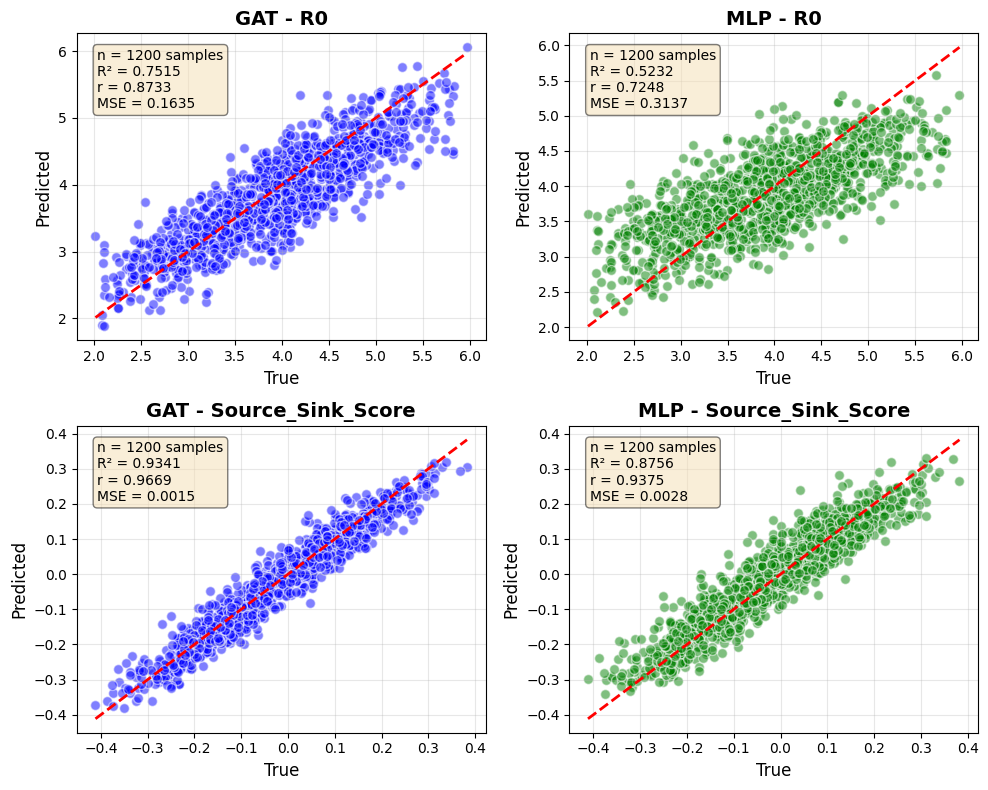


Label                Model      Params   Test MSE       R²
----------------------------------------------------------
R0                   GAT           426     0.1635   0.7515
R0                   MLP           497     0.3137   0.5232
Source_Sink_Score    GAT           426     0.0015   0.9341
Source_Sink_Score    MLP           497     0.0028   0.8756


In [5]:
# Plot 2x2 grid: rows = labels (R0, Source_Sink_Score), cols = models (GAT, MLP)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

model_names = ['GAT', 'MLP']  # GAT left, MLP right
colors = {'MLP': 'green', 'GAT': 'blue'}

for row, label_name in enumerate(labels):
    for col, model_name in enumerate(model_names):
        ax = axes[row, col]
        model = results[label_name][model_name]['model']
        mse = results[label_name][model_name]['test_loss']
        
        preds, true_labels = get_predictions(model, test_graphs, label_name)
        n_samples = len(preds)
        r2 = r2_score(true_labels, preds)
        corr = np.corrcoef(true_labels, preds)[0, 1]
        
        ax.scatter(true_labels, preds, alpha=0.5, color=colors[model_name], s=50, edgecolor='white')
        ax.plot([true_labels.min(), true_labels.max()], [true_labels.min(), true_labels.max()], 'r--', lw=2)
        ax.set_xlabel('True', fontsize=12)
        ax.set_ylabel('Predicted', fontsize=12)
        ax.set_title(f'{model_name} - {label_name}', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Stats - show n, R², r, MSE
        stats = f'n = {n_samples} samples\nR² = {r2:.4f}\nr = {corr:.4f}\nMSE = {mse:.4f}'
        ax.text(0.05, 0.95, stats, transform=ax.transAxes, va='top', fontsize=10,
                bbox=dict(boxstyle='round', fc='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Label':<20} {'Model':<8} {'Params':>8} {'Test MSE':>10} {'R²':>8}")
print("-"*58)
for label_name in labels:
    for model_name in model_names:
        model = results[label_name][model_name]['model']
        loss = results[label_name][model_name]['test_loss']
        preds, true_labels = get_predictions(model, test_graphs, label_name)
        params = sum(p.numel() for p in model.parameters())
        print(f"{label_name:<20} {model_name:<8} {params:>8} {loss:>10.4f} {r2_score(true_labels, preds):>8.4f}")

## 6. Different Migration Rate

Compare GAT vs MLP performance across datasets with different migration rates.

In [6]:
# Dataset configurations
datasets = ['500_1_MM0.002', '500_1_MM0.0025', '500_1_MM0.003', '500_1_MM0.005']
base_path = '/Users/lukelyu/Desktop/epidata'

# Store results for all datasets
all_results = {}

for dataset_name in datasets:
    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*60}")
    
    # Load graphs
    input_folder = f'{base_path}/{dataset_name}'
    graphs_dict = load_all_graphs(input_folder)
    graph_list_all = list(graphs_dict.values())
    graph_list_raw = [g for g in graph_list_all if not (g.ndata['Num_Samples'] == 0).any()]
    print(f"Loaded {len(graph_list_raw)}/{len(graph_list_all)} graphs")
    
    # Remove self-loops
    graph_list = []
    for g in graph_list_raw:
        src, dst = g.edges()
        mask = src != dst
        new_g = dgl.graph((src[mask], dst[mask]), num_nodes=g.num_nodes())
        for key, val in g.ndata.items():
            new_g.ndata[key] = val.clone()
        for key, val in g.edata.items():
            new_g.edata[key] = val[mask].clone()
        graph_list.append(new_g)
    
    # Stack features
    for g in graph_list:
        g.ndata['feat'] = torch.stack([g.ndata[f] for f in node_features], dim=1)
        g.edata['feat'] = torch.stack([g.edata[f] for f in edge_features], dim=1)
        for lbl in labels:
            g.ndata[f'label_{lbl}'] = g.ndata[lbl]
    
    # Train/val/test split - update global variables for train_model
    global train_graphs, val_graphs, test_graphs
    train_graphs, temp = train_test_split(graph_list, test_size=0.3, random_state=42)
    val_graphs, test_graphs = train_test_split(temp, test_size=0.5, random_state=42)
    all_g = train_graphs + val_graphs + test_graphs
    
    # Z-score normalization
    for i in range(len(node_features)):
        train_vals = torch.cat([g.ndata['feat'][:, i] for g in train_graphs])
        mean, std = train_vals.mean(), train_vals.std()
        for g in all_g:
            g.ndata['feat'][:, i] = (g.ndata['feat'][:, i] - mean) / std
    
    for i in range(len(edge_features)):
        train_vals = torch.cat([g.edata['feat'][:, i] for g in train_graphs])
        mean, std = train_vals.mean(), train_vals.std()
        for g in all_g:
            g.edata['feat'][:, i] = (g.edata['feat'][:, i] - mean) / std
    
    # Train models for both labels
    dataset_results = {}
    for label_name in labels:
        print(f"\n  Training for {label_name}...")
        
        # GAT
        gat = GAT(node_dim, edge_dim)
        test_gat, _, gat = train_model(gat, label_name, verbose=False)
        
        # MLP
        mlp = MLP(node_dim)
        test_mlp, _, mlp = train_model(mlp, label_name, verbose=False)
        
        # Get predictions on test set
        gat_preds, gat_labels = get_predictions(gat, test_graphs, label_name)
        mlp_preds, mlp_labels = get_predictions(mlp, test_graphs, label_name)
        
        dataset_results[label_name] = {
            'GAT': {'preds': gat_preds, 'labels': gat_labels, 'mse': test_gat, 'r2': r2_score(gat_labels, gat_preds)},
            'MLP': {'preds': mlp_preds, 'labels': mlp_labels, 'mse': test_mlp, 'r2': r2_score(mlp_labels, mlp_preds)}
        }
        print(f"    GAT: MSE={test_gat:.4f}, R²={dataset_results[label_name]['GAT']['r2']:.4f}")
        print(f"    MLP: MSE={test_mlp:.4f}, R²={dataset_results[label_name]['MLP']['r2']:.4f}")
    
    all_results[dataset_name] = dataset_results

print(f"\n{'='*60}")
print("All datasets processed!")
print(f"{'='*60}")


Dataset: 500_1_MM0.002
Found 500 node files

Successfully loaded 500 graphs
Loaded 500/500 graphs

  Training for R0...
    GAT: MSE=0.1435, R²=0.7944
    MLP: MSE=0.2786, R²=0.6009

  Training for Source_Sink_Score...
    GAT: MSE=0.0019, R²=0.9357
    MLP: MSE=0.0032, R²=0.8902

Dataset: 500_1_MM0.0025
Found 500 node files

Successfully loaded 500 graphs
Loaded 500/500 graphs

  Training for R0...
    GAT: MSE=0.1645, R²=0.7500
    MLP: MSE=0.3128, R²=0.5245

  Training for Source_Sink_Score...
    GAT: MSE=0.0015, R²=0.9329
    MLP: MSE=0.0028, R²=0.8769

Dataset: 500_1_MM0.003
Found 500 node files

Successfully loaded 500 graphs
Loaded 500/500 graphs

  Training for R0...
    GAT: MSE=0.2085, R²=0.6489
    MLP: MSE=0.3623, R²=0.3897

  Training for Source_Sink_Score...
    GAT: MSE=0.0014, R²=0.9303
    MLP: MSE=0.0024, R²=0.8738

Dataset: 500_1_MM0.005
Found 500 node files

Successfully loaded 500 graphs
Loaded 500/500 graphs

  Training for R0...
    GAT: MSE=0.2548, R²=0.5955
 

Saved: migration_rate_comparison.pdf


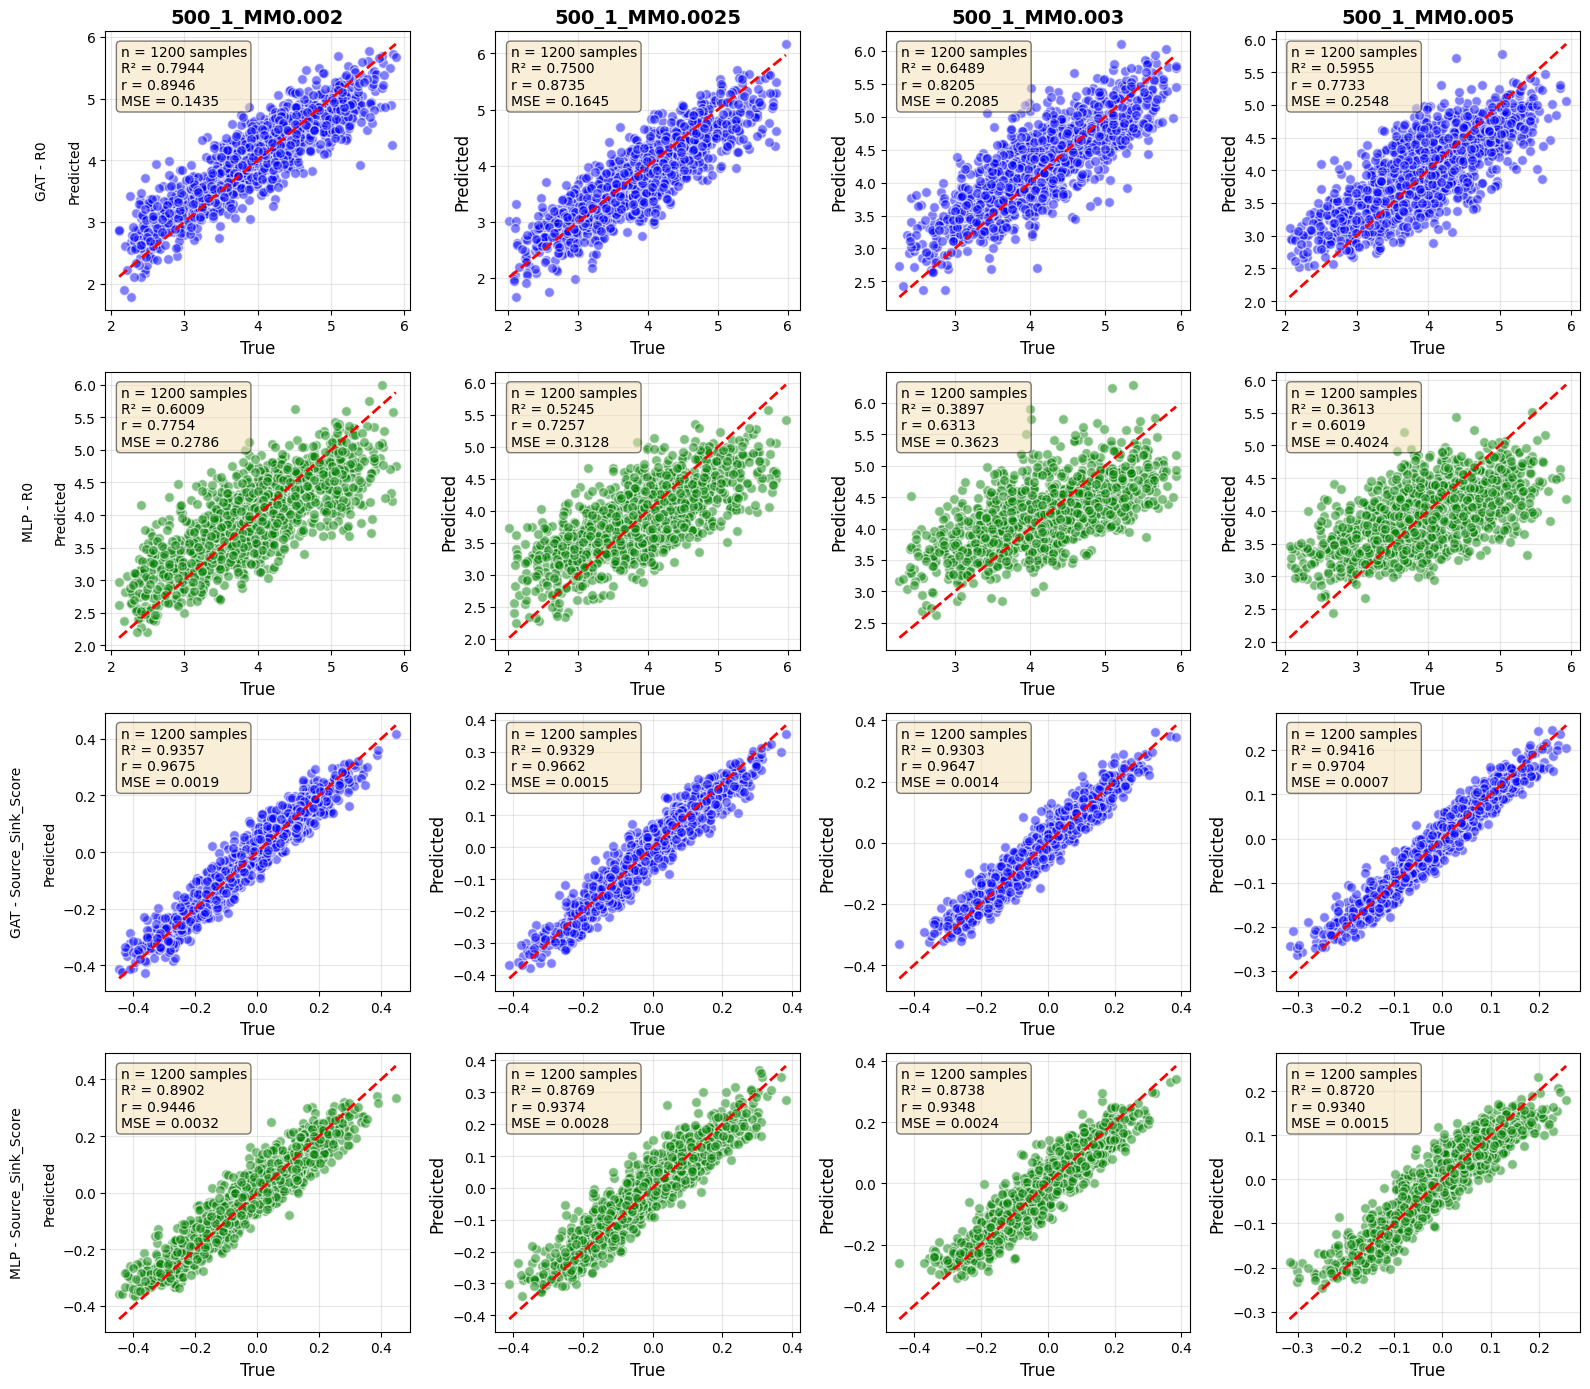


Dataset              Label                Model      Test MSE       R²
----------------------------------------------------------------------
500_1_MM0.002        R0                   GAT          0.1435   0.7944
500_1_MM0.002        R0                   MLP          0.2786   0.6009
500_1_MM0.002        Source_Sink_Score    GAT          0.0019   0.9357
500_1_MM0.002        Source_Sink_Score    MLP          0.0032   0.8902
500_1_MM0.0025       R0                   GAT          0.1645   0.7500
500_1_MM0.0025       R0                   MLP          0.3128   0.5245
500_1_MM0.0025       Source_Sink_Score    GAT          0.0015   0.9329
500_1_MM0.0025       Source_Sink_Score    MLP          0.0028   0.8769
500_1_MM0.003        R0                   GAT          0.2085   0.6489
500_1_MM0.003        R0                   MLP          0.3623   0.3897
500_1_MM0.003        Source_Sink_Score    GAT          0.0014   0.9303
500_1_MM0.003        Source_Sink_Score    MLP          0.0024   0.8738
500_1

In [7]:
# Summary plot: 4 rows (GAT-R0, MLP-R0, GAT-SSS, MLP-SSS) x 4 cols (datasets)
fig, axes = plt.subplots(4, 4, figsize=(16, 14))

colors = {'GAT': 'blue', 'MLP': 'green'}
row_configs = [
    ('R0', 'GAT'), ('R0', 'MLP'), 
    ('Source_Sink_Score', 'GAT'), ('Source_Sink_Score', 'MLP')
]

for row, (label_name, model_name) in enumerate(row_configs):
    for col, dataset_name in enumerate(datasets):
        ax = axes[row, col]
        res = all_results[dataset_name][label_name][model_name]
        
        n_samples = len(res['preds'])
        r2 = res['r2']
        corr = np.corrcoef(res['labels'], res['preds'])[0, 1]
        mse = res['mse']
        
        ax.scatter(res['labels'], res['preds'], alpha=0.5, color=colors[model_name], s=50, edgecolor='white')
        ax.plot([res['labels'].min(), res['labels'].max()], 
                [res['labels'].min(), res['labels'].max()], 'r--', lw=2)
        ax.set_xlabel('True', fontsize=12)
        ax.set_ylabel('Predicted', fontsize=12)
        ax.grid(True, alpha=0.3)
        
        # Dataset title only on first row
        if row == 0:
            ax.set_title(dataset_name, fontsize=14, fontweight='bold')
        
        # Stats - show n, R², r, MSE
        stats = f'n = {n_samples} samples\nR² = {r2:.4f}\nr = {corr:.4f}\nMSE = {mse:.4f}'
        ax.text(0.05, 0.95, stats, transform=ax.transAxes, va='top', fontsize=10,
                bbox=dict(boxstyle='round', fc='wheat', alpha=0.5))
        
        # Add model-label on left column
        if col == 0:
            ax.set_ylabel(f'{model_name} - {label_name}\n\nPredicted', fontsize=10)

plt.tight_layout()
fig.savefig('migration_rate_comparison.pdf', bbox_inches='tight', dpi=300)
print("Saved: migration_rate_comparison.pdf")
plt.show()

# Summary table
print(f"\n{'Dataset':<20} {'Label':<20} {'Model':<8} {'Test MSE':>10} {'R²':>8}")
print("-"*70)
for dataset_name in datasets:
    for label_name in labels:
        for model_name in ['GAT', 'MLP']:
            res = all_results[dataset_name][label_name][model_name]
            print(f"{dataset_name:<20} {label_name:<20} {model_name:<8} {res['mse']:>10.4f} {res['r2']:>8.4f}")